# Real-Time Hand Gesture Classification with MobileNet and OpenCV

This project builds an end-to-end computer vision pipeline for classifying rock-paper-scissors hand gestures from images and webcam input. It compares a custom convolutional neural network baseline against a MobileNet transfer learning model, then extends the best-performing approach toward real-time webcam inference using OpenCV.

The project was originally developed from a university computer vision assignment and later refactored into a standalone portfolio project focused on dataset preparation, model comparison, evaluation, and practical deployment.

## Project Goals

The main goals of this project are to:

- Prepare a balanced image dataset for rock-paper-scissors gesture classification.
- Build a custom CNN baseline using PyTorch.
- Apply transfer learning using MobileNet pretrained on ImageNet.
- Compare model performance using accuracy, confusion matrices, and error analysis.
- Explore real-time webcam inference using OpenCV.
- Present the project as a clean, reproducible AI/ML portfolio project.

## Project Workflow

The notebook follows this workflow:

1. Environment setup and configuration
2. Dataset setup and image discovery
3. Stratified train/dev/test split
4. Exploratory data analysis
5. PyTorch dataset and dataloader creation
6. Custom CNN baseline training
7. MobileNet transfer learning
8. Training curve visualization
9. Model evaluation and comparison
10. Error analysis and failure case inspection
11. Real-time webcam inference planning
12. Conclusion and future improvements

## Project Scope

This version focuses on static image classification and real-time frame-by-frame webcam inference. The model predicts one of three gesture classes: rock, paper, or scissors.

This project does not yet perform dynamic gesture recognition, hand tracking, or temporal video classification. These are listed as future improvements.

# 1. Environment Setup and Configuration

## 1.1 Imports and Reproducibility

This section imports the main libraries used throughout the project and sets a fixed random seed. Reproducibility is important in machine learning because dataset splits, model initialization, and training behavior can change between runs if randomness is not controlled.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

## 1.2 Random Seed

A fixed seed is used to make random operations more consistent across runs. This helps keep dataset splitting and model experiments easier to compare.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


## 1.3 Device Configuration

The notebook automatically selects the best available device:

- CUDA, if running on an NVIDIA GPU
- MPS, if running on Apple Silicon
- CPU, if no accelerator is available

This makes the notebook portable across different machines.

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## 1.4 Project Paths

The project uses a consistent folder structure so that data, outputs, and models are easy to manage. The notebook is stored inside the `notebooks/` folder, so paths are defined relative to the project root.

In [4]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "archive"
SPLITS_DIR = DATA_DIR / "splits"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [DATA_DIR, SPLITS_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Splits directory: {SPLITS_DIR}")
print(f"Outputs directory: {OUTPUTS_DIR}")
print(f"Models directory: {MODELS_DIR}")

Project root: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification
Raw data directory: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/data/archive
Splits directory: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/data/splits
Outputs directory: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs
Models directory: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/models


## 1.5 Class Labels

The classification task contains three hand gesture classes: rock, paper, and scissors. These labels are mapped to numeric IDs for model training.

In [5]:
CLASS_NAMES = ["rock", "paper", "scissors"]
CLASS_TO_IDX = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: class_name for class_name, idx in CLASS_TO_IDX.items()}

print(CLASS_TO_IDX)

{'rock': 0, 'paper': 1, 'scissors': 2}


# 2. Dataset Setup and Image Discovery

The original dataset is expected to be stored inside `data/archive/`, with one folder per class. This section scans the dataset directory, validates the class folders, and creates a dataframe containing each image path and its corresponding label.

## 2.1 Validate Dataset Directory

Before processing images, the notebook checks whether the expected dataset directory and class folders exist. This helps catch path issues early.

In [6]:
if not RAW_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Raw dataset directory not found: {RAW_DATA_DIR}\n"
        "Please place the dataset inside data/archive/ with class folders: rock, paper, scissors."
    )

missing_classes = [class_name for class_name in CLASS_NAMES if not (RAW_DATA_DIR / class_name).exists()]

if missing_classes:
    raise FileNotFoundError(f"Missing class folders: {missing_classes}")

print("Dataset directory found.")
print("Class folders found:", CLASS_NAMES)

Dataset directory found.
Class folders found: ['rock', 'paper', 'scissors']


## 2.2 Discover Image Files

The dataset is scanned for image files from each class folder. The result is stored in a dataframe with two columns:

- `path`: path to the image file
- `label`: class label of the image

In [7]:
image_extensions = {".jpg", ".jpeg", ".png"}

records = []

for class_name in CLASS_NAMES:
    class_dir = RAW_DATA_DIR / class_name
    
    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() in image_extensions:
            records.append({
                "path": str(image_path.relative_to(PROJECT_ROOT)),
                "label": class_name
            })

images_df = pd.DataFrame(records)

print(f"Total images found: {len(images_df)}")
images_df.head()

Total images found: 2717


,path,label
0,data/archive/rock/rock_213.png,rock
1,data/archive/rock/rock_575.png,rock
2,data/archive/rock/rock_561.png,rock
3,data/archive/rock/rock_207.png,rock
4,data/archive/rock/rock_549.png,rock


## 2.3 Check Class Distribution

A quick class count is used to confirm how many images were discovered for each gesture class.

In [8]:
class_counts = images_df["label"].value_counts().reindex(CLASS_NAMES)

class_counts

label
rock        907
paper       907
scissors    903
Name: count, dtype: int64

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2.4 Dataset Discovery Summary

The image discovery step creates a clean dataframe that will be used for stratified train/dev/test splitting. Each image is represented by its relative path and class label, which makes the dataset easier to manage across different machines.

# 3. Stratified Train/Dev/Test Split

The dataset is split into training, development, and test sets using a 60/20/20 ratio. Stratified splitting is used so that each split keeps approximately the same proportion of rock, paper, and scissors images.

This helps ensure that evaluation results are not biased by class imbalance.

## 3.1 Create Stratified Splits

The full image dataframe is first split into training and temporary data. The temporary data is then split equally into development and test sets. Both operations use stratification based on the class label.

In [9]:
train_df, temp_df = train_test_split(
    images_df,
    test_size=0.40,
    stratify=images_df["label"],
    random_state=SEED,
    shuffle=True
)

devtest_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
    shuffle=True
)

print(f"Training samples: {len(train_df)}")
print(f"Devtest samples: {len(devtest_df)}")
print(f"Test samples: {len(test_df)}")

Training samples: 1630
Devtest samples: 543
Test samples: 544


## 3.2 Save Split CSV Files

The generated splits are saved as CSV files so they can be reused consistently across experiments.

In [10]:
train_csv_path = SPLITS_DIR / "train.csv"
devtest_csv_path = SPLITS_DIR / "devtest.csv"
test_csv_path = SPLITS_DIR / "test.csv"

train_df.to_csv(train_csv_path, index=False)
devtest_df.to_csv(devtest_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print(f"Saved: {train_csv_path}")
print(f"Saved: {devtest_csv_path}")
print(f"Saved: {test_csv_path}")

Saved: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/data/splits/train.csv
Saved: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/data/splits/devtest.csv
Saved: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/data/splits/test.csv


## 3.3 Verify Split Distribution

The class distribution of each split is checked to confirm that stratified splitting preserved class balance.

In [11]:
split_distribution = pd.DataFrame({
    "train": train_df["label"].value_counts().reindex(CLASS_NAMES),
    "devtest": devtest_df["label"].value_counts().reindex(CLASS_NAMES),
    "test": test_df["label"].value_counts().reindex(CLASS_NAMES)
})

split_distribution

,train,devtest,test
label,,,
rock,544,181,182
paper,544,181,182
scissors,542,181,180


<Figure size 800x500 with 0 Axes>

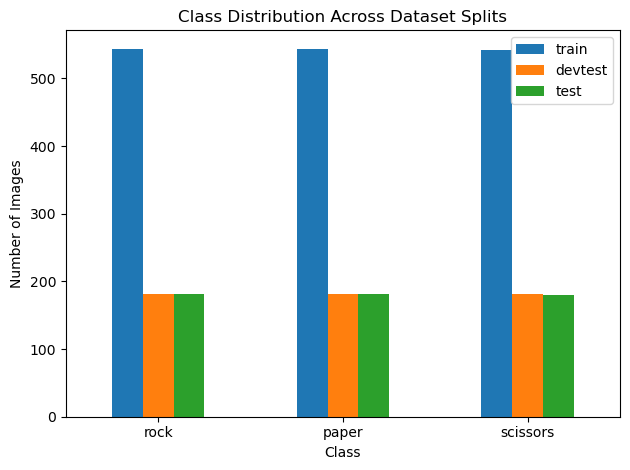

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/split_class_distribution.png


In [12]:
plt.figure(figsize=(8, 5))
split_distribution.plot(kind="bar")
plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()

split_distribution_path = FIGURES_DIR / "split_class_distribution.png"
plt.savefig(split_distribution_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {split_distribution_path}")

## 3.4 Split Summary

The generated train, devtest, and test sets maintain similar class proportions across all three gesture classes. This creates a fair experimental setup for comparing the custom CNN baseline and MobileNet transfer learning model.

# 4. Exploratory Data Analysis

This section explores the prepared dataset splits visually. The goal is to confirm that the dataset contains sensible examples from each class and that the image files can be loaded correctly before model training.

## 4.1 Load Saved Dataset Splits

The saved CSV files are loaded back into dataframes. This makes the notebook reproducible because later sections use the same split files instead of creating new random splits.

In [13]:
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
devtest_df = pd.read_csv(SPLITS_DIR / "devtest.csv")
test_df = pd.read_csv(SPLITS_DIR / "test.csv")

print(f"Train set: {len(train_df)} images")
print(f"Devtest set: {len(devtest_df)} images")
print(f"Test set: {len(test_df)} images")

Train set: 1630 images
Devtest set: 543 images
Test set: 544 images


## 4.2 Display Sample Images by Split

A small grid of sample images is displayed to inspect examples from each class across the training, development, and test sets.

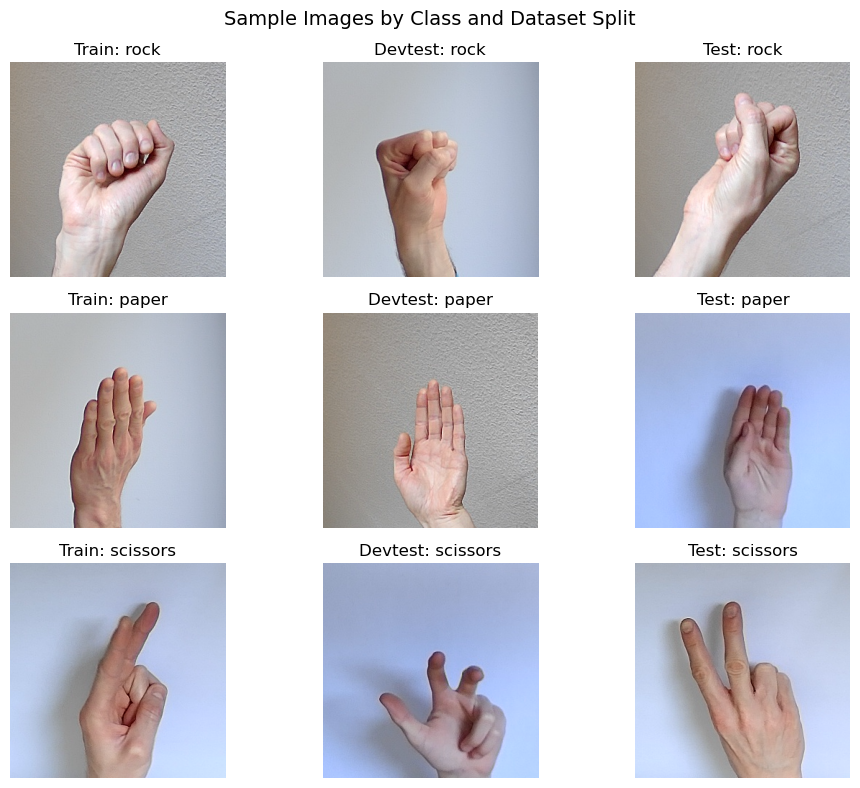

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/sample_images_by_split.png


In [14]:
def get_sample_image(df, class_name):
    sample_row = df[df["label"] == class_name].sample(1, random_state=SEED).iloc[0]
    image_path = PROJECT_ROOT / sample_row["path"]
    return Image.open(image_path).convert("RGB"), sample_row["label"]


splits = {
    "Train": train_df,
    "Devtest": devtest_df,
    "Test": test_df
}

fig, axes = plt.subplots(
    nrows=len(CLASS_NAMES),
    ncols=len(splits),
    figsize=(10, 8)
)

for row_idx, class_name in enumerate(CLASS_NAMES):
    for col_idx, (split_name, split_df) in enumerate(splits.items()):
        image, label = get_sample_image(split_df, class_name)
        ax = axes[row_idx, col_idx]
        ax.imshow(image)
        ax.set_title(f"{split_name}: {label}")
        ax.axis("off")

plt.suptitle("Sample Images by Class and Dataset Split", fontsize=14)
plt.tight_layout()

sample_grid_path = FIGURES_DIR / "sample_images_by_split.png"
plt.savefig(sample_grid_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {sample_grid_path}")

## 4.3 Inspect Image Sizes

Image size consistency is important because deep learning models require fixed input dimensions. This check helps identify whether resizing transforms will be required in the PyTorch pipeline.

In [15]:
image_sizes = []

for _, row in images_df.iterrows():
    image_path = PROJECT_ROOT / row["path"]
    with Image.open(image_path) as img:
        image_sizes.append({
            "width": img.width,
            "height": img.height,
            "label": row["label"]
        })

image_sizes_df = pd.DataFrame(image_sizes)
image_sizes_df.head()

,width,height,label
0,300,300,rock
1,300,300,rock
2,300,300,rock
3,300,300,rock
4,300,300,rock


In [16]:
image_sizes_df[["width", "height"]].describe()

,width,height
count,2717.0,2717.0
mean,300.0,300.0
std,0.0,0.0
min,300.0,300.0
25%,300.0,300.0
50%,300.0,300.0
75%,300.0,300.0
max,300.0,300.0


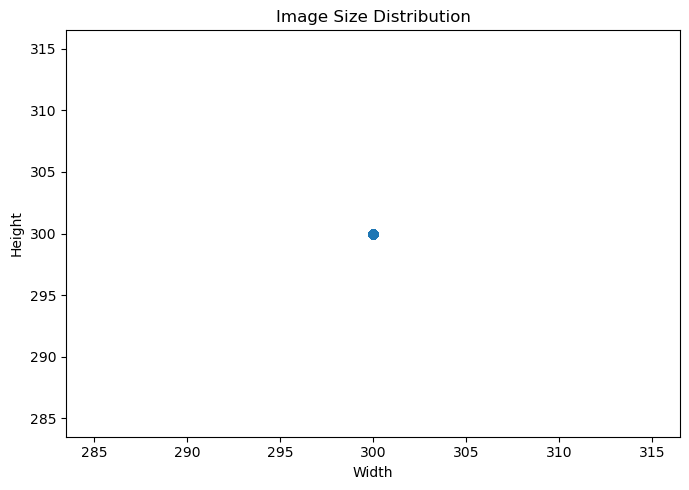

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/image_size_distribution.png


In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(image_sizes_df["width"], image_sizes_df["height"], alpha=0.5)
plt.title("Image Size Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()

image_size_path = FIGURES_DIR / "image_size_distribution.png"
plt.savefig(image_size_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {image_size_path}")

## 4.4 EDA Summary

The exploratory analysis confirmed that all three gesture classes are represented consistently across the dataset splits. Visual inspection showed that the images are correctly labelled and follow a similar visual style, which is useful for supervised image classification.

The image dimension analysis also revealed that all images in the dataset already have a uniform size of 300×300 pixels. This simplifies preprocessing because no additional aspect-ratio correction or image normalization strategy is required before resizing for model training.

Overall, the dataset appears clean, balanced, and suitable for both the custom CNN baseline and MobileNet transfer learning experiments.

# 5. PyTorch Dataset and DataLoader Pipeline

This section converts the CSV-based dataset splits into PyTorch datasets and dataloaders. A custom dataset class is used to load images from file paths, apply preprocessing transforms, and convert text labels into numeric class IDs.

A clean data pipeline is important because it makes model training, validation, and testing consistent across experiments.

## 5.1 Image Preprocessing Transforms

The images in the dataset are already 300×300 pixels, but they are resized to 224×224 to align with common ImageNet-based model input sizes such as MobileNet.

The transform pipeline also converts images into tensors and normalizes pixel values using ImageNet mean and standard deviation values. This is especially important for transfer learning because MobileNet was originally trained using ImageNet-style normalization.

In [18]:
IMG_SIZE = 224
BATCH_SIZE = 32

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Image size: 224x224
Batch size: 32


## 5.2 Custom PyTorch Dataset

The custom dataset reads image paths and labels from a dataframe. Each image is loaded using PIL, converted to RGB, transformed into a tensor, and paired with its encoded numeric label.

In [19]:
class GestureDataset(Dataset):
    def __init__(self, dataframe, project_root, class_to_idx, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.project_root = Path(project_root)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        image_path = self.project_root / row["path"]
        image = Image.open(image_path).convert("RGB")
        
        label_name = row["label"]
        label = self.class_to_idx[label_name]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

## 5.3 Create Dataset Objects

The training set uses the training transform, while the development and test sets use the evaluation transform. At this stage, both transforms are intentionally simple so that the baseline experiments remain easy to interpret.

In [20]:
train_dataset = GestureDataset(
    dataframe=train_df,
    project_root=PROJECT_ROOT,
    class_to_idx=CLASS_TO_IDX,
    transform=train_transform
)

devtest_dataset = GestureDataset(
    dataframe=devtest_df,
    project_root=PROJECT_ROOT,
    class_to_idx=CLASS_TO_IDX,
    transform=eval_transform
)

test_dataset = GestureDataset(
    dataframe=test_df,
    project_root=PROJECT_ROOT,
    class_to_idx=CLASS_TO_IDX,
    transform=eval_transform
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Devtest dataset size: {len(devtest_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 1630
Devtest dataset size: 543
Test dataset size: 544


## 5.4 Create DataLoaders

DataLoaders handle batching, shuffling, and efficient loading during training and evaluation. The training dataloader is shuffled so the model does not learn from images in a fixed order. The development and test dataloaders are not shuffled because they are used for evaluation.

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

devtest_loader = DataLoader(
    devtest_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

batch_images, batch_labels = next(iter(train_loader))

print(f"Image batch shape: {batch_images.shape}")
print(f"Label batch shape: {batch_labels.shape}")
print(f"Example labels: {batch_labels[:10].tolist()}")

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Example labels: [2, 1, 0, 2, 0, 1, 2, 2, 2, 1]


## 5.5 Visual Batch Inspection

Before training, a batch of images is visualized after reversing the normalization. This confirms that the dataloader is returning images and labels correctly.

In [22]:
def denormalize_image(tensor_image, mean, std):
    image = tensor_image.clone().detach().cpu()
    
    for channel, mean_value, std_value in zip(image, mean, std):
        channel.mul_(std_value).add_(mean_value)
    
    image = image.clamp(0, 1)
    image = image.permute(1, 2, 0).numpy()
    
    return image

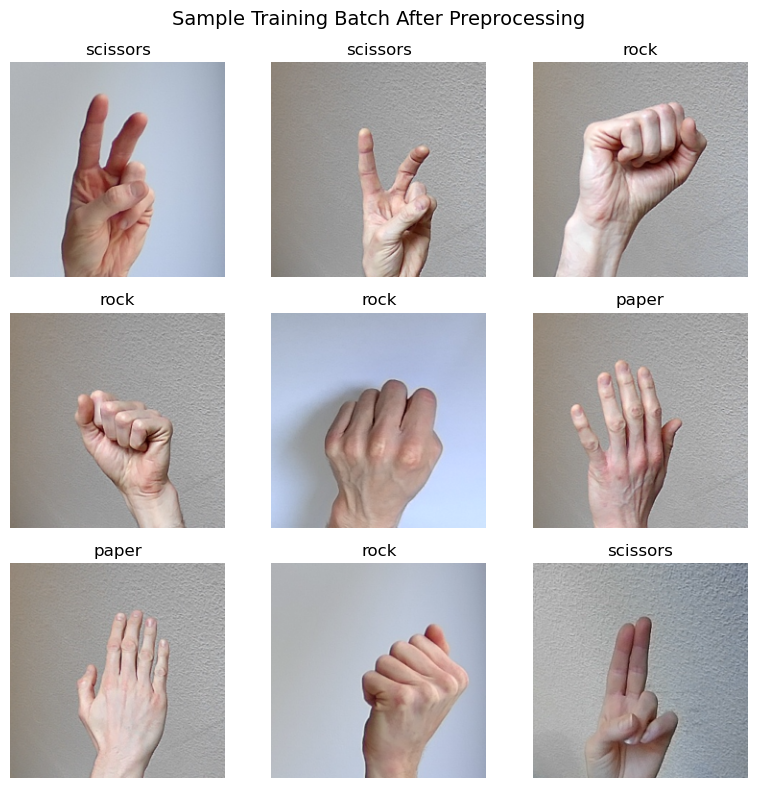

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/preprocessed_training_batch.png


In [23]:
images, labels = next(iter(train_loader))

num_images = 9
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for idx, ax in enumerate(axes.flat):
    image = denormalize_image(images[idx], imagenet_mean, imagenet_std)
    label = IDX_TO_CLASS[labels[idx].item()]
    
    ax.imshow(image)
    ax.set_title(label)
    ax.axis("off")

plt.suptitle("Sample Training Batch After Preprocessing", fontsize=14)
plt.tight_layout()

batch_preview_path = FIGURES_DIR / "preprocessed_training_batch.png"
plt.savefig(batch_preview_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {batch_preview_path}")

## 5.6 Data Pipeline Summary

The PyTorch data pipeline successfully converts image paths and labels from CSV files into batched tensors ready for model training. Images are resized to 224×224, normalized using ImageNet statistics, and loaded through separate dataloaders for training, development, and testing.

This shared data pipeline will be used for both the custom CNN baseline and the MobileNet transfer learning model, making the comparison between the two approaches more consistent.

# 6. Custom CNN Baseline

This section implements a custom convolutional neural network as a baseline model. The baseline is trained from scratch on the rock-paper-scissors dataset without using pretrained weights.

The purpose of this model is to provide a simple reference point for comparison against MobileNet transfer learning in the next stage.

## 6.1 Baseline Model Design

The custom CNN uses a sequence of convolution, ReLU activation, and max-pooling layers. Convolutional layers learn spatial patterns such as edges, hand shapes, and gesture-specific visual features. Max-pooling reduces the spatial size of feature maps while preserving important information.

The model ends with fully connected layers that convert the learned image features into class predictions for rock, paper, and scissors.

In [24]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CustomCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 6.2 Initialize the Baseline Model

The model is moved to the selected device. On this machine, the notebook can use MPS if available, which allows training to run on Apple Silicon acceleration.

In [25]:
custom_cnn = CustomCNN(num_classes=len(CLASS_NAMES)).to(device)

print(custom_cnn)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)


## 6.3 Loss Function and Optimizer

Cross-entropy loss is used because this is a multi-class classification task. The Adam optimizer is used because it is a reliable general-purpose optimizer for deep learning experiments.

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(custom_cnn.parameters(), lr=0.001)

NUM_EPOCHS = 10

print(f"Training for {NUM_EPOCHS} epochs on device: {device}")

Training for 10 epochs on device: mps


## 6.4 Training and Validation Functions

The training function updates model weights using the training set. The evaluation function measures loss and accuracy on a validation or test set without updating weights.

Separating these functions keeps the notebook cleaner and makes the same logic reusable for MobileNet later.

In [27]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        _, predictions = torch.max(outputs, dim=1)
        
        running_loss += loss.item() * images.size(0)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy


def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            _, predictions = torch.max(outputs, dim=1)
            
            running_loss += loss.item() * images.size(0)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy

## 6.5 Train the Custom CNN

The model is trained for a fixed number of epochs. After each epoch, performance is measured on the development set. The best model checkpoint is saved based on development accuracy.

In [28]:
checkpoint_dir = MODELS_DIR / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

custom_cnn_checkpoint_path = checkpoint_dir / "custom_cnn_best.pth"

history_custom_cnn = {
    "train_loss": [],
    "train_accuracy": [],
    "devtest_loss": [],
    "devtest_accuracy": []
}

best_devtest_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model=custom_cnn,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )
    
    devtest_loss, devtest_accuracy = evaluate_model(
        model=custom_cnn,
        dataloader=devtest_loader,
        criterion=criterion,
        device=device
    )
    
    history_custom_cnn["train_loss"].append(train_loss)
    history_custom_cnn["train_accuracy"].append(train_accuracy)
    history_custom_cnn["devtest_loss"].append(devtest_loss)
    history_custom_cnn["devtest_accuracy"].append(devtest_accuracy)
    
    if devtest_accuracy > best_devtest_accuracy:
        best_devtest_accuracy = devtest_accuracy
        torch.save(custom_cnn.state_dict(), custom_cnn_checkpoint_path)
    
    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Dev Loss: {devtest_loss:.4f} | "
        f"Dev Acc: {devtest_accuracy:.4f}"
    )

print(f"Best devtest accuracy: {best_devtest_accuracy:.4f}")
print(f"Best model saved to: {custom_cnn_checkpoint_path}")

Epoch [1/10] Train Loss: 0.8312 | Train Acc: 0.6294 | Dev Loss: 0.5327 | Dev Acc: 0.7919
Epoch [2/10] Train Loss: 0.4134 | Train Acc: 0.8423 | Dev Loss: 0.3114 | Dev Acc: 0.8858
Epoch [3/10] Train Loss: 0.2053 | Train Acc: 0.9276 | Dev Loss: 0.2301 | Dev Acc: 0.9116
Epoch [4/10] Train Loss: 0.1080 | Train Acc: 0.9571 | Dev Loss: 0.2513 | Dev Acc: 0.9171
Epoch [5/10] Train Loss: 0.0526 | Train Acc: 0.9865 | Dev Loss: 0.1401 | Dev Acc: 0.9448
Epoch [6/10] Train Loss: 0.0374 | Train Acc: 0.9865 | Dev Loss: 0.1978 | Dev Acc: 0.9355
Epoch [7/10] Train Loss: 0.0425 | Train Acc: 0.9840 | Dev Loss: 0.1473 | Dev Acc: 0.9558
Epoch [8/10] Train Loss: 0.0245 | Train Acc: 0.9933 | Dev Loss: 0.1656 | Dev Acc: 0.9503
Epoch [9/10] Train Loss: 0.0338 | Train Acc: 0.9865 | Dev Loss: 0.2859 | Dev Acc: 0.9282
Epoch [10/10] Train Loss: 0.0399 | Train Acc: 0.9859 | Dev Loss: 0.2445 | Dev Acc: 0.9319
Best devtest accuracy: 0.9558
Best model saved to: /Users/razinrayanrahat/Documents/python_projects/real-time

## 6.6 Training Curve Visualization

Training curves are used to inspect how the model learned over time. The loss curve shows whether the model is minimizing error, while the accuracy curve shows whether performance improves across epochs.

Comparing training and development curves also helps identify possible overfitting.

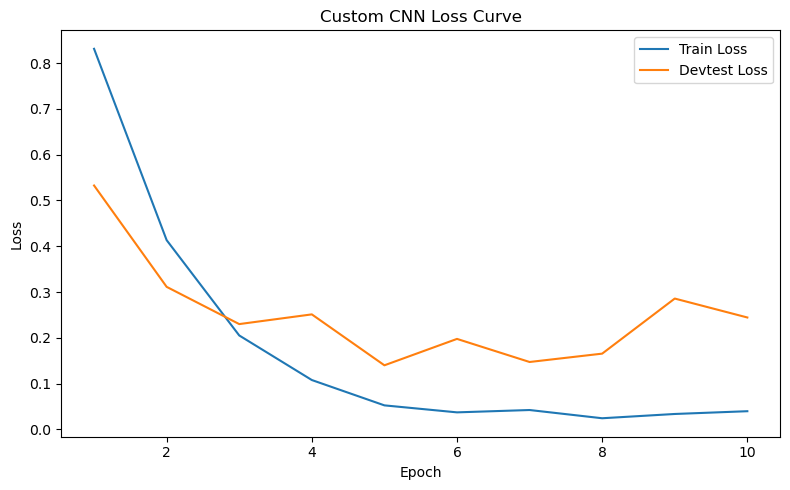

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/custom_cnn_loss_curve.png


In [29]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_custom_cnn["train_loss"], label="Train Loss")
plt.plot(epochs, history_custom_cnn["devtest_loss"], label="Devtest Loss")
plt.title("Custom CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

custom_cnn_loss_path = FIGURES_DIR / "custom_cnn_loss_curve.png"
plt.savefig(custom_cnn_loss_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {custom_cnn_loss_path}")

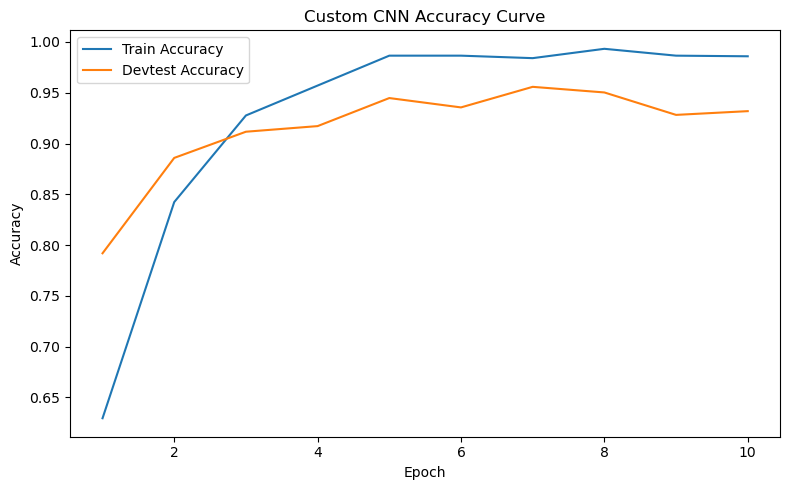

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/custom_cnn_accuracy_curve.png


In [30]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_custom_cnn["train_accuracy"], label="Train Accuracy")
plt.plot(epochs, history_custom_cnn["devtest_accuracy"], label="Devtest Accuracy")
plt.title("Custom CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

custom_cnn_accuracy_path = FIGURES_DIR / "custom_cnn_accuracy_curve.png"
plt.savefig(custom_cnn_accuracy_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {custom_cnn_accuracy_path}")

## 6.7 Custom CNN Baseline Summary

The custom CNN successfully learned meaningful visual patterns from the gesture dataset and achieved strong development accuracy after several training epochs. Training accuracy increased steadily throughout the experiment, while development accuracy reached its best performance at epoch 7 with approximately 95.6% accuracy.

The training and development curves also revealed early signs of overfitting. While training loss continued decreasing and training accuracy approached 99%, development performance became less stable after the best epoch. This suggests that the model gradually began memorizing training-specific patterns instead of improving generalization.

To address this, the best-performing model checkpoint was saved automatically based on development accuracy. This ensures that later evaluation uses the version of the model that generalized best to unseen data rather than the final epoch.

# 7. Custom CNN Evaluation

This section evaluates the best saved Custom CNN checkpoint on the test set. The test set was not used during training or model selection, so it provides a more reliable estimate of final model performance.

The evaluation includes test accuracy, a confusion matrix, and examples of misclassified images.

## 7.1 Load the Best Custom CNN Checkpoint

During training, the best model was saved based on development accuracy. This checkpoint is loaded before test evaluation so that the final results use the model version that generalized best during validation.

In [31]:
custom_cnn_best = CustomCNN(num_classes=len(CLASS_NAMES)).to(device)
custom_cnn_best.load_state_dict(torch.load(custom_cnn_checkpoint_path, map_location=device))
custom_cnn_best.eval()

print(f"Loaded best Custom CNN checkpoint from: {custom_cnn_checkpoint_path}")

Loaded best Custom CNN checkpoint from: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/models/checkpoints/custom_cnn_best.pth


## 7.2 Generate Test Predictions

The model is evaluated on the test dataloader. Predicted labels, true labels, and confidence scores are stored for later analysis.

In [32]:
def get_predictions(model, dataloader, device):
    model.eval()
    
    all_true_labels = []
    all_pred_labels = []
    all_confidences = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            confidences, predictions = torch.max(probabilities, dim=1)
            
            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predictions.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())
    
    return np.array(all_true_labels), np.array(all_pred_labels), np.array(all_confidences)

In [33]:
custom_cnn_true, custom_cnn_pred, custom_cnn_conf = get_predictions(
    model=custom_cnn_best,
    dataloader=test_loader,
    device=device
)

custom_cnn_test_accuracy = accuracy_score(custom_cnn_true, custom_cnn_pred)

print(f"Custom CNN Test Accuracy: {custom_cnn_test_accuracy:.4f}")

Custom CNN Test Accuracy: 0.9449


## 7.3 Confusion Matrix

A confusion matrix shows how predictions are distributed across the actual classes. It helps identify which gestures are classified correctly and which classes are commonly confused.

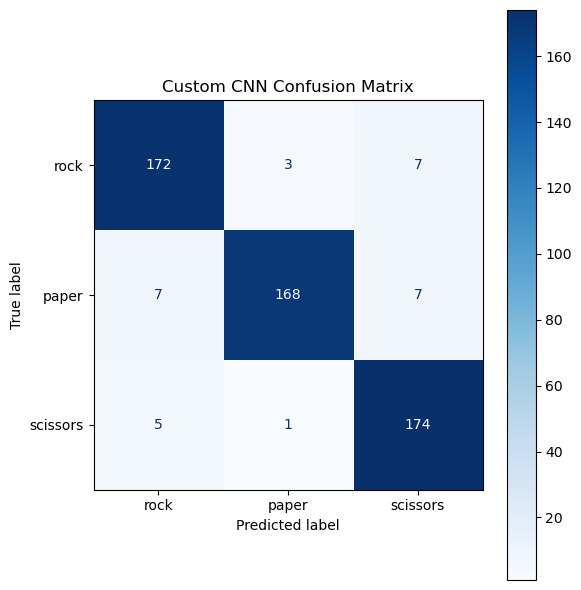

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/confusion_matrices/custom_cnn_confusion_matrix.png


In [34]:
conf_matrix = confusion_matrix(custom_cnn_true, custom_cnn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Custom CNN Confusion Matrix")
plt.tight_layout()

confusion_dir = OUTPUTS_DIR / "confusion_matrices"
confusion_dir.mkdir(parents=True, exist_ok=True)

custom_cnn_cm_path = confusion_dir / "custom_cnn_confusion_matrix.png"
plt.savefig(custom_cnn_cm_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {custom_cnn_cm_path}")

## 7.4 Misclassified Examples

Misclassified examples are inspected to understand the kinds of visual patterns that caused the model to make mistakes. This helps identify limitations of the baseline model beyond accuracy alone.

In [37]:
misclassified_indices = np.where(custom_cnn_true != custom_cnn_pred)[0]

print(f"Number of misclassified test images: {len(misclassified_indices)}")

Number of misclassified test images: 30


In [38]:
def show_misclassified_examples(
    dataframe,
    true_labels,
    pred_labels,
    confidences,
    misclassified_indices,
    project_root,
    idx_to_class,
    save_path,
    max_images=9
):
    if len(misclassified_indices) == 0:
        print("No misclassified examples to display.")
        return
    
    selected_indices = misclassified_indices[:max_images]
    num_images = len(selected_indices)
    
    cols = 3
    rows = int(np.ceil(num_images / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(10, 3.5 * rows))
    
    if rows == 1:
        axes = np.array([axes])
    
    axes = axes.flatten()
    
    for plot_idx, data_idx in enumerate(selected_indices):
        row = dataframe.iloc[data_idx]
        image_path = project_root / row["path"]
        image = Image.open(image_path).convert("RGB")
        
        true_label = idx_to_class[int(true_labels[data_idx])]
        pred_label = idx_to_class[int(pred_labels[data_idx])]
        confidence = confidences[data_idx]
        
        axes[plot_idx].imshow(image)
        axes[plot_idx].set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})"
        )
        axes[plot_idx].axis("off")
    
    for empty_idx in range(num_images, len(axes)):
        axes[empty_idx].axis("off")
    
    plt.suptitle("Custom CNN Misclassified Test Examples", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Saved figure to: {save_path}")

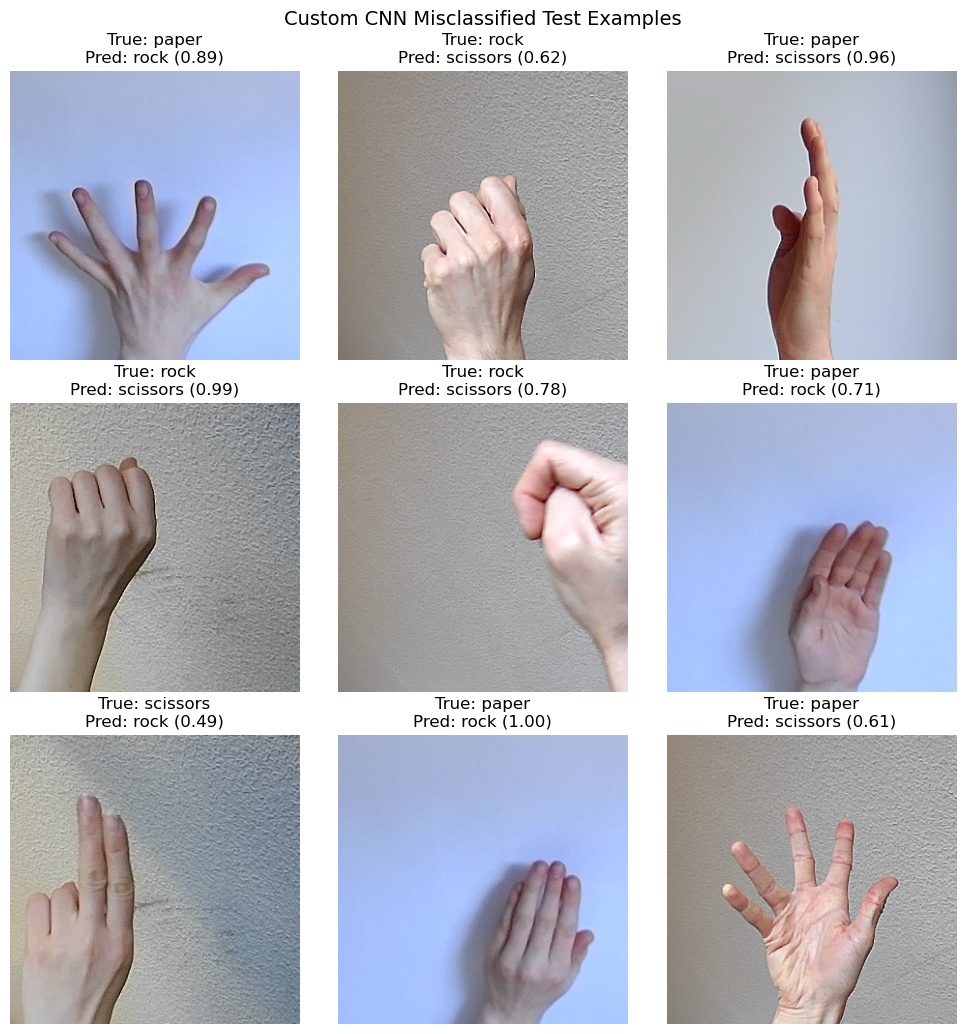

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/sample_predictions/custom_cnn_misclassified_examples.png


In [39]:
sample_predictions_dir = OUTPUTS_DIR / "sample_predictions"
sample_predictions_dir.mkdir(parents=True, exist_ok=True)

custom_cnn_misclassified_path = sample_predictions_dir / "custom_cnn_misclassified_examples.png"

show_misclassified_examples(
    dataframe=test_df,
    true_labels=custom_cnn_true,
    pred_labels=custom_cnn_pred,
    confidences=custom_cnn_conf,
    misclassified_indices=misclassified_indices,
    project_root=PROJECT_ROOT,
    idx_to_class=IDX_TO_CLASS,
    save_path=custom_cnn_misclassified_path,
    max_images=9
)

## 7.5 Custom CNN Evaluation Summary

The Custom CNN achieved approximately 94.5% test accuracy on the held-out test set, demonstrating that the model successfully learned meaningful visual patterns from the gesture dataset.

The confusion matrix showed that the model performed best on the scissors class, while paper produced the highest number of misclassifications. Inspection of the failed predictions revealed that unusual hand orientations, partially closed fingers, and side-view gestures were more difficult for the model to classify correctly.

Several incorrect predictions were also associated with high confidence scores, indicating that the model had learned strong but sometimes overly specific visual associations from the training data. These results suggest that the baseline CNN learned useful gesture representations, but its generalization ability remains sensitive to viewpoint and gesture variation.

# 8. MobileNet Transfer Learning

This section applies transfer learning using MobileNet pretrained on ImageNet. Instead of training a network entirely from scratch, transfer learning reuses visual features learned from a large-scale image dataset.

The pretrained feature extractor is frozen, while the final classifier layer is replaced and trained on the rock-paper-scissors dataset.

## 8.1 Why Transfer Learning?

Training deep convolutional networks from scratch often requires very large datasets and long training times. Transfer learning provides a more efficient alternative by starting from a model that has already learned useful visual representations from millions of images.

MobileNet is designed to be lightweight and computationally efficient, making it suitable for real-time computer vision applications and edge-device deployment.

In [40]:
mobilenet_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /Users/razinrayanrahat/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:02<00:00, 4.91MB/s]


## 8.2 Freeze Feature Extractor

The pretrained convolutional layers are frozen so that their weights are not updated during training. Only the final classifier layer will learn task-specific gesture patterns.

In [41]:
for param in mobilenet_model.parameters():
    param.requires_grad = False

## 8.3 Replace the Classification Head

The original MobileNet classifier is designed for ImageNet's 1000 classes. The final layer is replaced with a smaller classifier that predicts the three gesture classes used in this project.

In [42]:
mobilenet_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(
        in_features=mobilenet_model.last_channel,
        out_features=len(CLASS_NAMES)
    )
)

mobilenet_model = mobilenet_model.to(device)

print(mobilenet_model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)


## 8.4 Loss Function and Optimizer

Only the classifier parameters are optimized because the feature extractor remains frozen.

In [43]:
mobilenet_criterion = nn.CrossEntropyLoss()

mobilenet_optimizer = torch.optim.Adam(
    mobilenet_model.classifier.parameters(),
    lr=0.001
)

MOBILENET_EPOCHS = 5

print(f"Training MobileNet for {MOBILENET_EPOCHS} epochs")

Training MobileNet for 5 epochs


## 8.5 Train MobileNet

The same training and evaluation functions used for the Custom CNN are reused here. This keeps the comparison between models fair and consistent.

In [44]:
mobilenet_checkpoint_path = checkpoint_dir / "mobilenet_best.pth"

history_mobilenet = {
    "train_loss": [],
    "train_accuracy": [],
    "devtest_loss": [],
    "devtest_accuracy": []
}

best_mobilenet_dev_acc = 0.0

for epoch in range(MOBILENET_EPOCHS):
    
    train_loss, train_accuracy = train_one_epoch(
        model=mobilenet_model,
        dataloader=train_loader,
        criterion=mobilenet_criterion,
        optimizer=mobilenet_optimizer,
        device=device
    )
    
    devtest_loss, devtest_accuracy = evaluate_model(
        model=mobilenet_model,
        dataloader=devtest_loader,
        criterion=mobilenet_criterion,
        device=device
    )
    
    history_mobilenet["train_loss"].append(train_loss)
    history_mobilenet["train_accuracy"].append(train_accuracy)
    history_mobilenet["devtest_loss"].append(devtest_loss)
    history_mobilenet["devtest_accuracy"].append(devtest_accuracy)
    
    if devtest_accuracy > best_mobilenet_dev_acc:
        best_mobilenet_dev_acc = devtest_accuracy
        torch.save(mobilenet_model.state_dict(), mobilenet_checkpoint_path)
    
    print(
        f"Epoch [{epoch+1}/{MOBILENET_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Dev Loss: {devtest_loss:.4f} | "
        f"Dev Acc: {devtest_accuracy:.4f}"
    )

print(f"Best MobileNet Dev Accuracy: {best_mobilenet_dev_acc:.4f}")

Epoch [1/5] Train Loss: 0.7937 | Train Acc: 0.7632 | Dev Loss: 0.5494 | Dev Acc: 0.9098
Epoch [2/5] Train Loss: 0.4581 | Train Acc: 0.9202 | Dev Loss: 0.3627 | Dev Acc: 0.9466
Epoch [3/5] Train Loss: 0.3388 | Train Acc: 0.9282 | Dev Loss: 0.2878 | Dev Acc: 0.9448
Epoch [4/5] Train Loss: 0.2811 | Train Acc: 0.9454 | Dev Loss: 0.2444 | Dev Acc: 0.9632
Epoch [5/5] Train Loss: 0.2459 | Train Acc: 0.9429 | Dev Loss: 0.2137 | Dev Acc: 0.9613
Best MobileNet Dev Accuracy: 0.9632


## 8.6 MobileNet Training Curves

The MobileNet training curves are visualized to inspect convergence behavior and compare learning dynamics against the Custom CNN baseline.

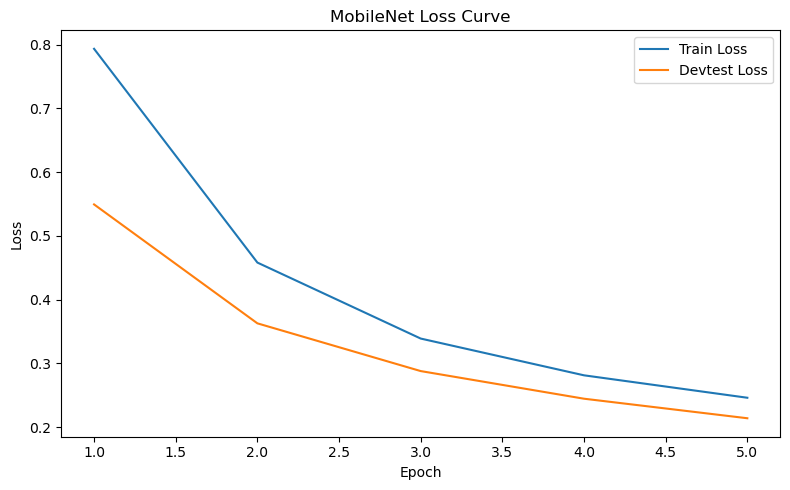

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/mobilenet_loss_curve.png


In [45]:
epochs = range(1, MOBILENET_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_mobilenet["train_loss"], label="Train Loss")
plt.plot(epochs, history_mobilenet["devtest_loss"], label="Devtest Loss")
plt.title("MobileNet Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

mobilenet_loss_path = FIGURES_DIR / "mobilenet_loss_curve.png"
plt.savefig(mobilenet_loss_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {mobilenet_loss_path}")

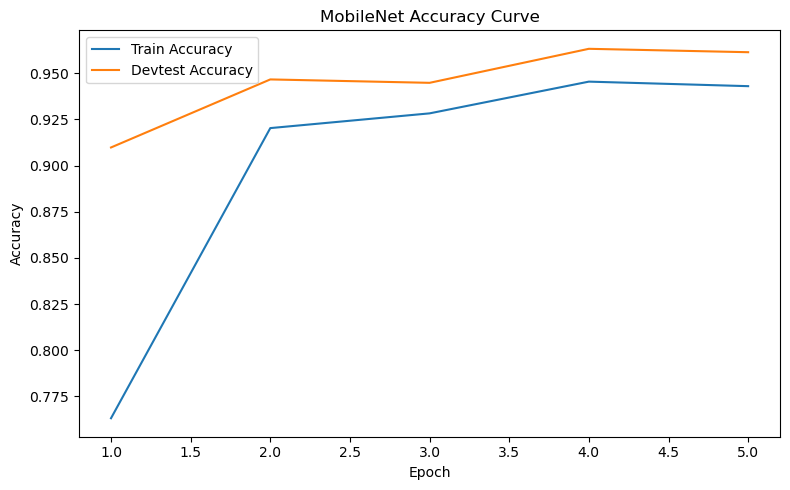

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/mobilenet_accuracy_curve.png


In [46]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_mobilenet["train_accuracy"], label="Train Accuracy")
plt.plot(epochs, history_mobilenet["devtest_accuracy"], label="Devtest Accuracy")
plt.title("MobileNet Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

mobilenet_accuracy_path = FIGURES_DIR / "mobilenet_accuracy_curve.png"
plt.savefig(mobilenet_accuracy_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {mobilenet_accuracy_path}")

## 8.7 MobileNet Training Summary

The MobileNet transfer learning model achieved strong development accuracy within only a few training epochs, demonstrating the effectiveness of pretrained visual representations for small image classification datasets.

Compared to the Custom CNN baseline, MobileNet converged more quickly and showed more stable validation behavior throughout training. The gap between training and development performance also remained relatively small, suggesting better generalization and reduced overfitting.

Because the pretrained feature extractor was frozen, the model was able to reuse visual knowledge learned from ImageNet while adapting only the final classifier layer to the gesture classification task. This resulted in efficient training and strong performance with limited data.